# Pinterest Monte Carlo Revenue Simulation

So the idea here is pretty simple: instead of building one revenue forecast and pretending we know what's going to happen, we run 10,000 versions of the future where we let the key variables wiggle around randomly. Then we look at the spread of outcomes and ask: how often does Pinterest's revenue actually go *down*? How often does it break $5B? What's the most likely range?

Monte Carlo simulation sounds intimidating but its really just a fancy for loop with some randomness baked in. The name comes from the casino in Monaco, which I think is a perfect metaphor for financial forecasting.

**Data Source:** Pinterest 10-K filings (FY2024, FY2025), SEC EDGAR

## Setup

*just the basics: numpy for random number generation, matplotlib for charts, pandas for organizing results*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)  # makes results reproducible every time you run it
print('Ready to go.')

Ready to go.


## Setting Up the Parameters

Each parameter gets a mean (our best guess) and a standard deviation (how much it could realistically swing). I pulled these from Pinterest's actual 2021 to 2025 performance.

Quick note on the engagement parameter: I set the mean slightly negative at -3%. That's the whole AI disruption thesis in one number. If ChatGPT and friends start eating into Pinterest's discovery use case, engagement drops, and that means fewer ad impressions, which means less revenue. The std dev of 7% means some simulations will see engagement *increase* (Pinterest successfully integrates AI) and others will see it crater. Thats the whole point of running this.

| Parameter | Mean | Std Dev | Why this number |
|-----------|------|---------|-----------|
| US ARPU Growth | +3% | 6% | Was 14% in 2024, decelerated to 6% in 2025 |
| Europe ARPU Growth | +15% | 8% | Strong at +21% in 2025, but could swing either way |
| ROW ARPU Growth | +25% | 10% | Fastest growing (+40% in 2025), highest uncertainty |
| MAU Growth | +8% | 4% | Pretty steady historically at 11-12% |
| Engagement Change | -3% | 7% | The AI disruption variable (see note above) |
| Ad Price Change | -10% | 8% | Prices have been declining 14-22% per year, structural |

In [ ]:
N = 10_000  # number of simulations

# 2025 actuals from the 10-K
BASE_US = 3173    # US & Canada revenue ($M)
BASE_EU = 775     # Europe revenue ($M)
BASE_ROW = 274    # Rest of World revenue ($M)
CURRENT = 4222    # Total

# (mean, std_dev) for each parameter
params = {
    'us_arpu_growth':  (0.03, 0.06),
    'eu_arpu_growth':  (0.15, 0.08),
    'row_arpu_growth': (0.25, 0.10),
    'mau_growth':      (0.08, 0.04),
    'engagement_chg':  (-0.03, 0.07),
    'ad_price_chg':    (-0.10, 0.08),
}

print(f'Base revenue: ${CURRENT:,}M')
print(f'Simulations to run: {N:,}')

Base revenue: $4,222M
Simulations to run: 10,000


## Running the Simulation

Here's where it actually happens. For each of the 10,000 runs, we:
1. Draw a random value for each parameter from a normal distribution
2. Calculate a "volume factor" (basically: more users times more engagement equals more ad impressions)
3. Apply everything to get a revenue number for each region
4. Store it

The `np.random.normal()` function is doing most of the heavy lifting here. It draws from a bell curve centered on our mean with the spread we defined. So most draws will be close to the mean, but occasionally you'll get a wild one. Thats what makes this interesting.

In [ ]:
results = []

for i in range(N):
    # draw random values for this simulation
    us_g = np.random.normal(*params['us_arpu_growth'])
    eu_g = np.random.normal(*params['eu_arpu_growth'])
    row_g = np.random.normal(*params['row_arpu_growth'])
    mau = np.random.normal(*params['mau_growth'])
    engage = np.random.normal(*params['engagement_chg'])
    ad_price = np.random.normal(*params['ad_price_chg'])
    
    # volume = more/fewer users * more/less engagement
    volume = (1 + mau) * (1 + engage)
    
    # revenue by region
    us_rev = BASE_US * volume * (1 + us_g)
    eu_rev = BASE_EU * volume * (1 + eu_g)
    row_rev = BASE_ROW * volume * (1 + row_g)
    
    results.append({
        'total': us_rev + eu_rev + row_rev,
        'us': us_rev, 'eu': eu_rev, 'row': row_rev,
        'mau_growth': mau, 'engagement': engage,
        'us_arpu_growth': us_g,
    })

df = pd.DataFrame(results)
print(f'Done! Generated {len(df):,} scenarios.')

Done! Generated 10,000 scenarios.


## Results

Alright, moment of truth. Let's see what 10,000 possible futures look like.

In [ ]:
print('=' * 45)
print('SIMULATION RESULTS')
print('=' * 45)
print(f'  Mean Revenue:     ${df["total"].mean():,.0f}M')
print(f'  Median Revenue:   ${df["total"].median():,.0f}M')
print(f'  Std Deviation:    ${df["total"].std():,.0f}M')
print(f'  5th Percentile:   ${df["total"].quantile(0.05):,.0f}M')
print(f'  95th Percentile:  ${df["total"].quantile(0.95):,.0f}M')
print()
print(f'  P(Rev < $4.0B):   {(df["total"] < 4000).mean():.1%}')
print(f'  P(Rev declines):  {(df["total"] < CURRENT).mean():.1%}')
print(f'  P(Rev > $5.0B):   {(df["total"] > 5000).mean():.1%}')
print('=' * 45)

SIMULATION RESULTS
  Mean Revenue:     $4,714M
  Median Revenue:   $4,708M
  Std Deviation:    $440M
  5th Percentile:   $4,011M
  95th Percentile:  $5,456M

  P(Rev < $4.0B):   4.7%
  P(Rev declines):  13.0%
  P(Rev > $5.0B):   25.1%


Okay so this is interesting. The average outcome across 10,000 simulations is about $4.7B, which is roughly 12% above where Pinterest is right now. So the base case is *growth*, not decline.

But: 13% of simulations show revenue actually falling below today's $4.2B. That's about 1 in 8. Not the end of the world, but definitely not nothing either. And only about 5% of scenarios drop below $4B, which would be a genuinely bad year.

The 90% confidence interval (5th to 95th percentile) is $4.0B to $5.5B. If I were presenting this to a leadership team, I'd say anything below $4B should probably trigger some kind of contingency plan.

## Chart 1: Revenue Distribution

Let's actually see what the distribution looks like. The red dotted line is where Pinterest sits today, and the orange dashed line is the mean across all simulations.

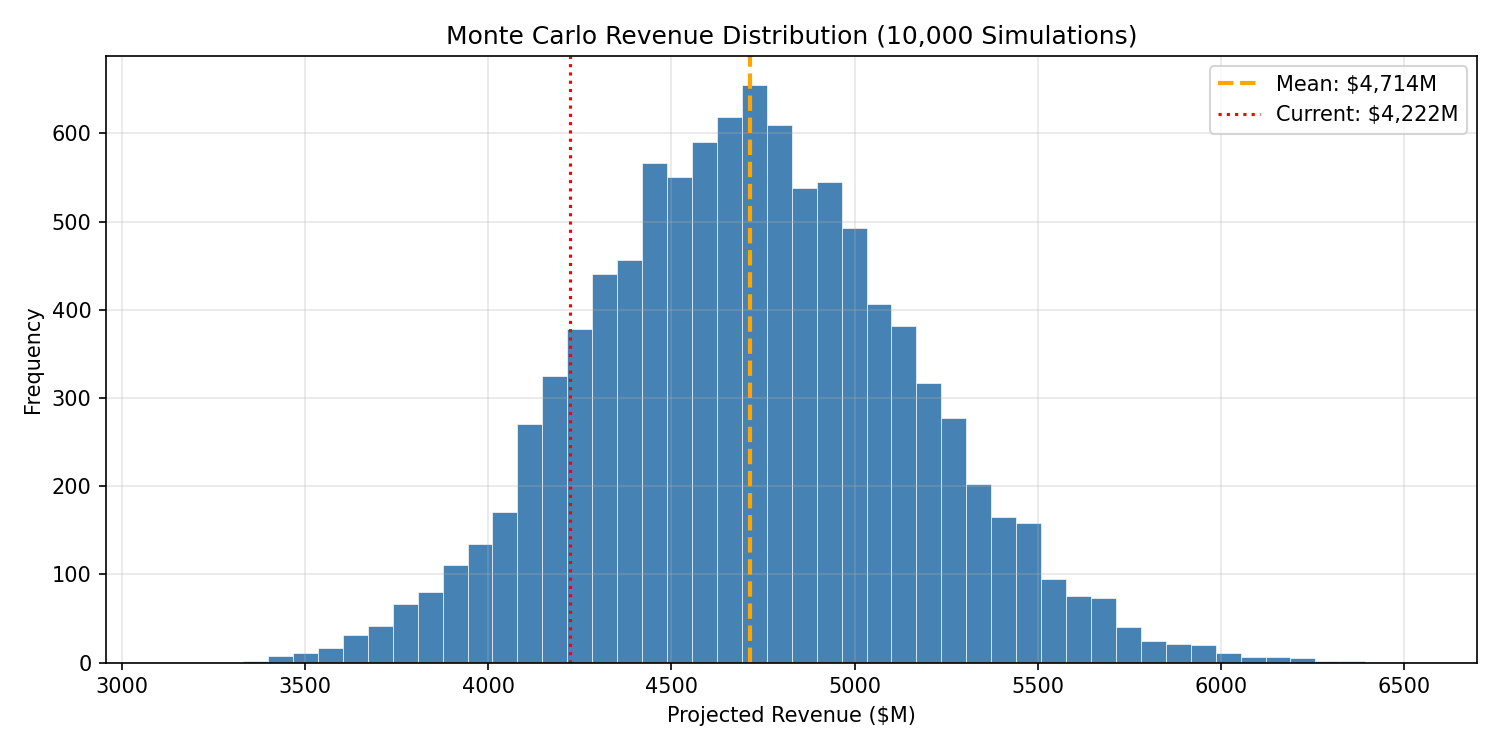

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['total'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(df['total'].mean(), color='orange', lw=2, ls='--', label=f'Mean: ${df["total"].mean():,.0f}M')
ax.axvline(CURRENT, color='red', lw=1.5, ls=':', label=f'Current: ${CURRENT:,}M')

ax.set_xlabel('Projected Revenue ($M)')
ax.set_ylabel('Frequency')
ax.set_title('Monte Carlo Revenue Distribution (10,000 Simulations)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

I like this chart because you can immediately see that the bulk of outcomes are to the *right* of the current revenue line (which is good). But there's a meaningful left tail that dips below $4B. That tail is basically the "AI eats Pinterest's lunch" scenario playing out across a bunch of simulations at once.

## Chart 2: What Moves Revenue the Most?

This is called a tornado chart (I didn't know that before this project, looked it up). The idea is simple: for each variable, we look at what happens to revenue when that variable is in its worst 10% vs its best 10%. The wider the bar, the more that variable matters.

I only included the three biggest drivers here because the others (EU ARPU, ROW ARPU, ad price) had relatively small spreads compared to these.

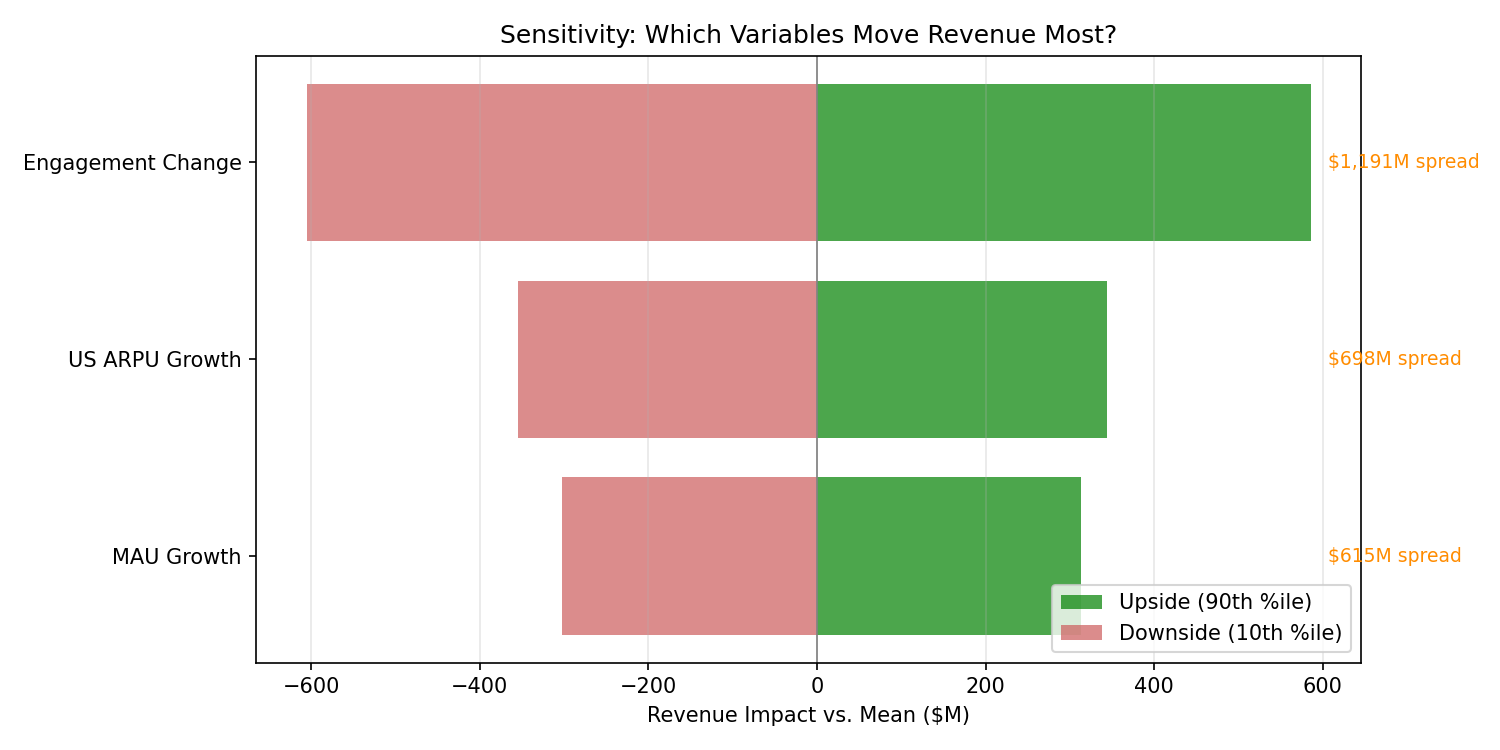

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

variables = {'Engagement Change': 'engagement', 'US ARPU Growth': 'us_arpu_growth', 'MAU Growth': 'mau_growth'}
mean_rev = df['total'].mean()
labels, lows, highs, spreads = [], [], [], []

for label, col in variables.items():
    low_rev = df.loc[df[col] <= df[col].quantile(0.10), 'total'].mean()
    high_rev = df.loc[df[col] >= df[col].quantile(0.90), 'total'].mean()
    labels.append(label)
    lows.append(low_rev - mean_rev)
    highs.append(high_rev - mean_rev)
    spreads.append(high_rev - low_rev)

# sort by spread
order = np.argsort(spreads)
labels = [labels[i] for i in order]
lows = [lows[i] for i in order]
highs = [highs[i] for i in order]
spreads = [spreads[i] for i in order]

y_pos = range(len(labels))
ax.barh(y_pos, highs, color='green', alpha=0.7, label='Upside (90th %ile)')
ax.barh(y_pos, lows, color='indianred', alpha=0.7, label='Downside (10th %ile)')
ax.axvline(0, color='gray', lw=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Revenue Impact vs. Mean ($M)')
ax.set_title('Sensitivity: Which Variables Move Revenue Most?')
ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)

for i, spread in enumerate(spreads):
    ax.text(max(highs) + 20, i, f'${spread:,.0f}M spread', va='center', fontsize=9, color='darkorange')

plt.tight_layout()
plt.show()

This is the chart that tells the strategic story. Engagement has a $1.2 *billion* dollar spread between the bad and good scenarios. That's basically saying: the single biggest thing that determines Pinterest's revenue trajectory is whether users keep showing up and scrolling.

Which makes sense when you think about their business model. Revenue = Users × Engagement × Ads × Price. If engagement drops, ad inventory drops. And since Pinterest has been growing revenue entirely through volume (ads served up 49%, but prices *down* 22%), they have no pricing power to compensate. It's all volume. And engagement IS volume.

This is where the AI risk actually lives. Not in some abstract "disruption" narrative, but in this specific variable: do people keep opening Pinterest, or do they ask a chatbot instead?

## Chart 3: Regional Revenue Ranges

Box plots for each region showing the simulated range. The red diamonds show the 2025 actuals.

*(I always forget how to read box plots so note to self: the box is the 25th to 75th percentile, the orange line is the median, and the whiskers extend to roughly the 5th and 95th)*

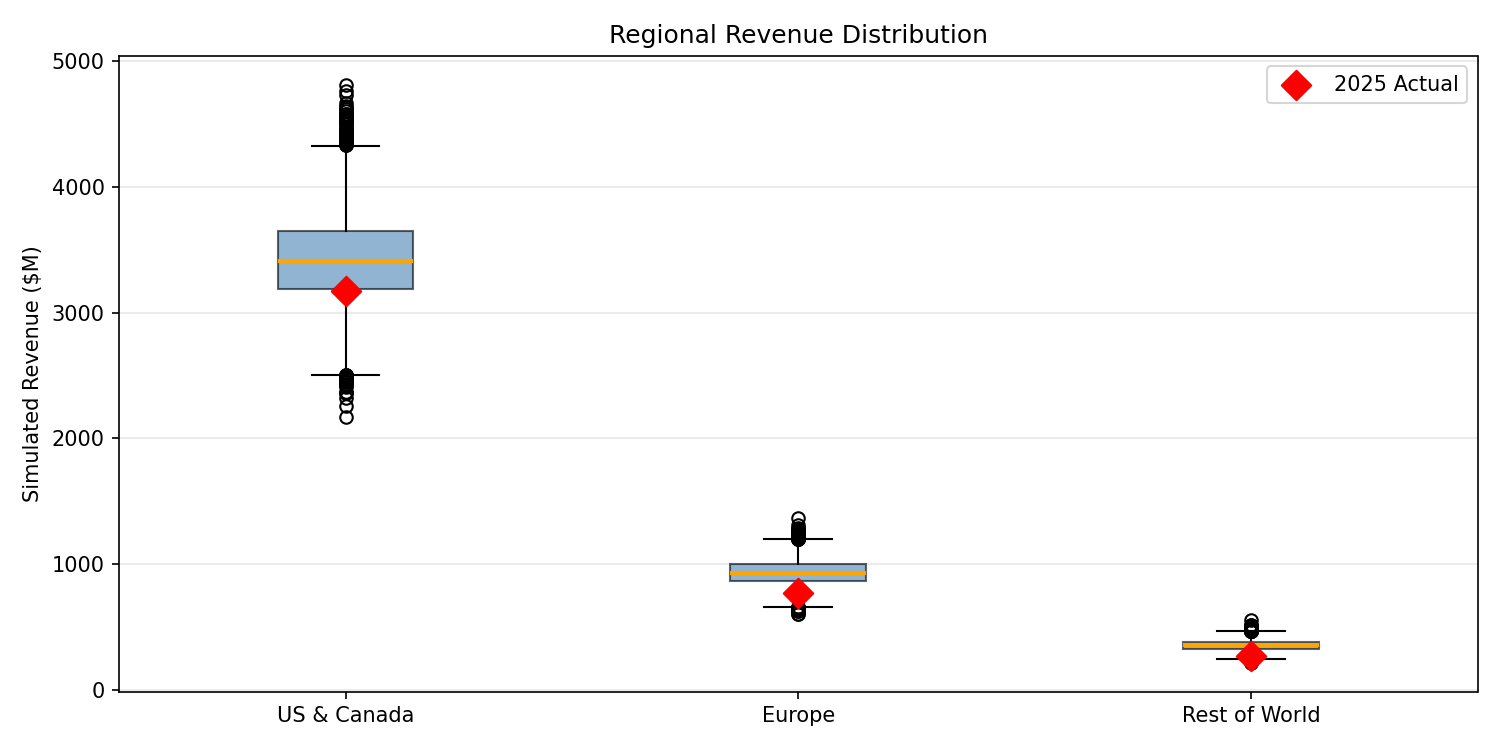

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot([df['us'], df['eu'], df['row']],
                tick_labels=['US & Canada', 'Europe', 'Rest of World'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='orange', linewidth=2))

# mark 2025 actuals
for i, val in enumerate([BASE_US, BASE_EU, BASE_ROW]):
    ax.scatter(i + 1, val, color='red', s=100, marker='D', zorder=5,
               label='2025 Actual' if i == 0 else '')

ax.set_ylabel('Simulated Revenue ($M)')
ax.set_title('Regional Revenue Distribution')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

You can really see the concentration risk here. The US box is enormous in absolute terms compared to Europe and ROW. Almost all of the variance in total revenue is being driven by what happens in the US market.

The flip side (which I think is the more interesting strategic takeaway): Europe and ROW have a lot of room to grow. If Pinterest can close even part of that ARPU gap internationally, the overall revenue distribution shifts right and becomes less dependent on the US. That would be the healthy version of growth.

## Chart 4: Cumulative Probability

This one is actually my favorite even though it looks deceptively simple. You pick a revenue number on the x-axis, read up to the curve, and that tells you the probability of landing *at or below* that number.

So for example if you go to $5B on the x-axis and read across, you get about 75%. That means theres a 75% chance revenue comes in below $5B (or put another way, a 25% chance it exceeds $5B).

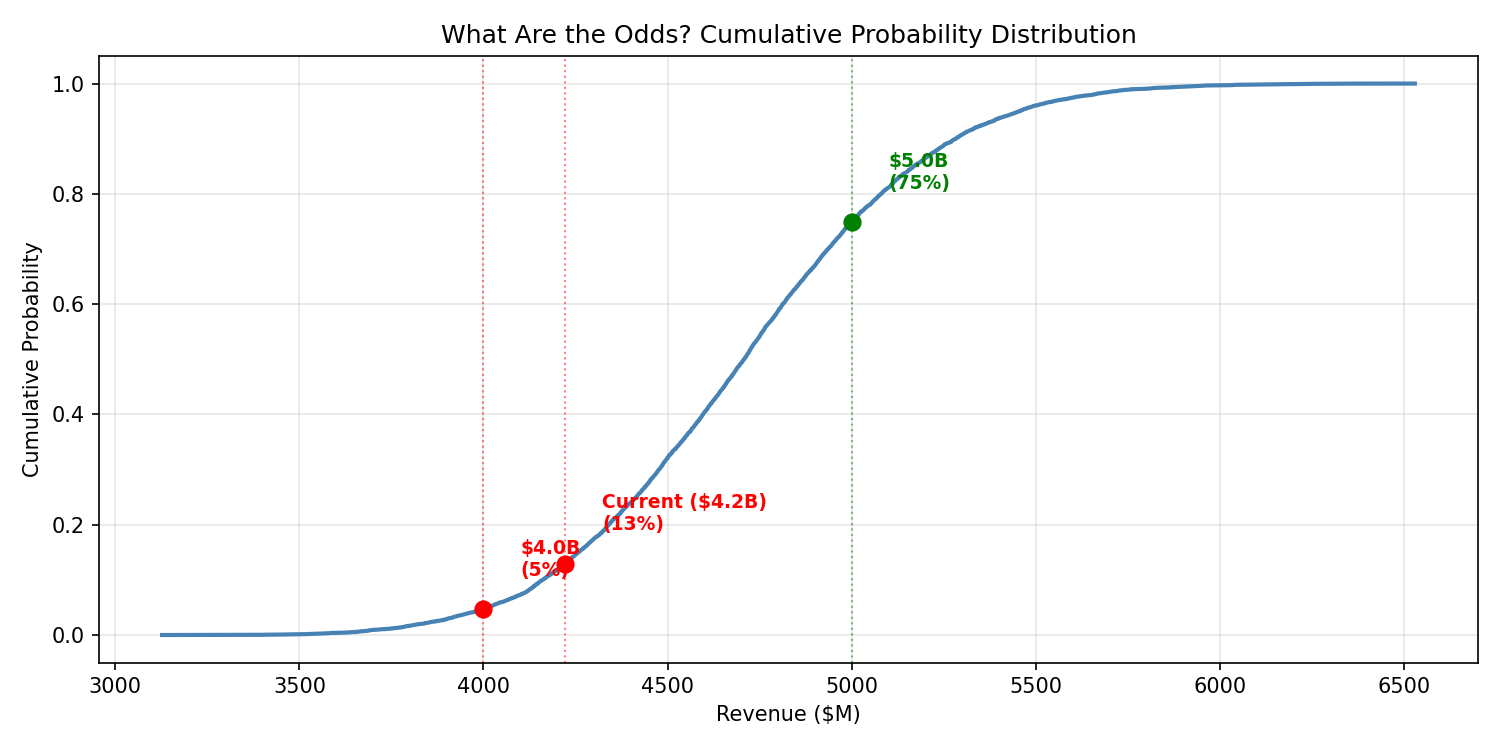

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sorted_rev = np.sort(df['total'])
cumulative = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)
ax.plot(sorted_rev, cumulative, color='steelblue', linewidth=2)

# mark key thresholds
for val, color, label in [(4000, 'red', '$4.0B'), (CURRENT, 'red', f'Current (${CURRENT/1000:.1f}B)'), (5000, 'green', '$5.0B')]:
    prob = (df['total'] <= val).mean()
    ax.axvline(val, color=color, lw=1, ls=':', alpha=0.5)
    ax.scatter(val, prob, color=color, s=60, zorder=5)
    ax.annotate(f'{label}\n({prob:.0%})', xy=(val, prob), xytext=(val+100, prob+0.06),
                fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Revenue ($M)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('What Are the Odds? Cumulative Probability Distribution')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Chart 5: Revenue vs. Key Drivers

Last one. These scatter plots show the relationship between each driver and total revenue across all 10,000 simulations. Each dot is one simulation run. The orange line is a simple linear fit and the r value tells us the correlation strength.

What I was looking for here: which variable has the tightest relationship with the outcome? If r is close to 1 it means that variable basically determines the result. If its closer to 0, it has less predictive power on its own.

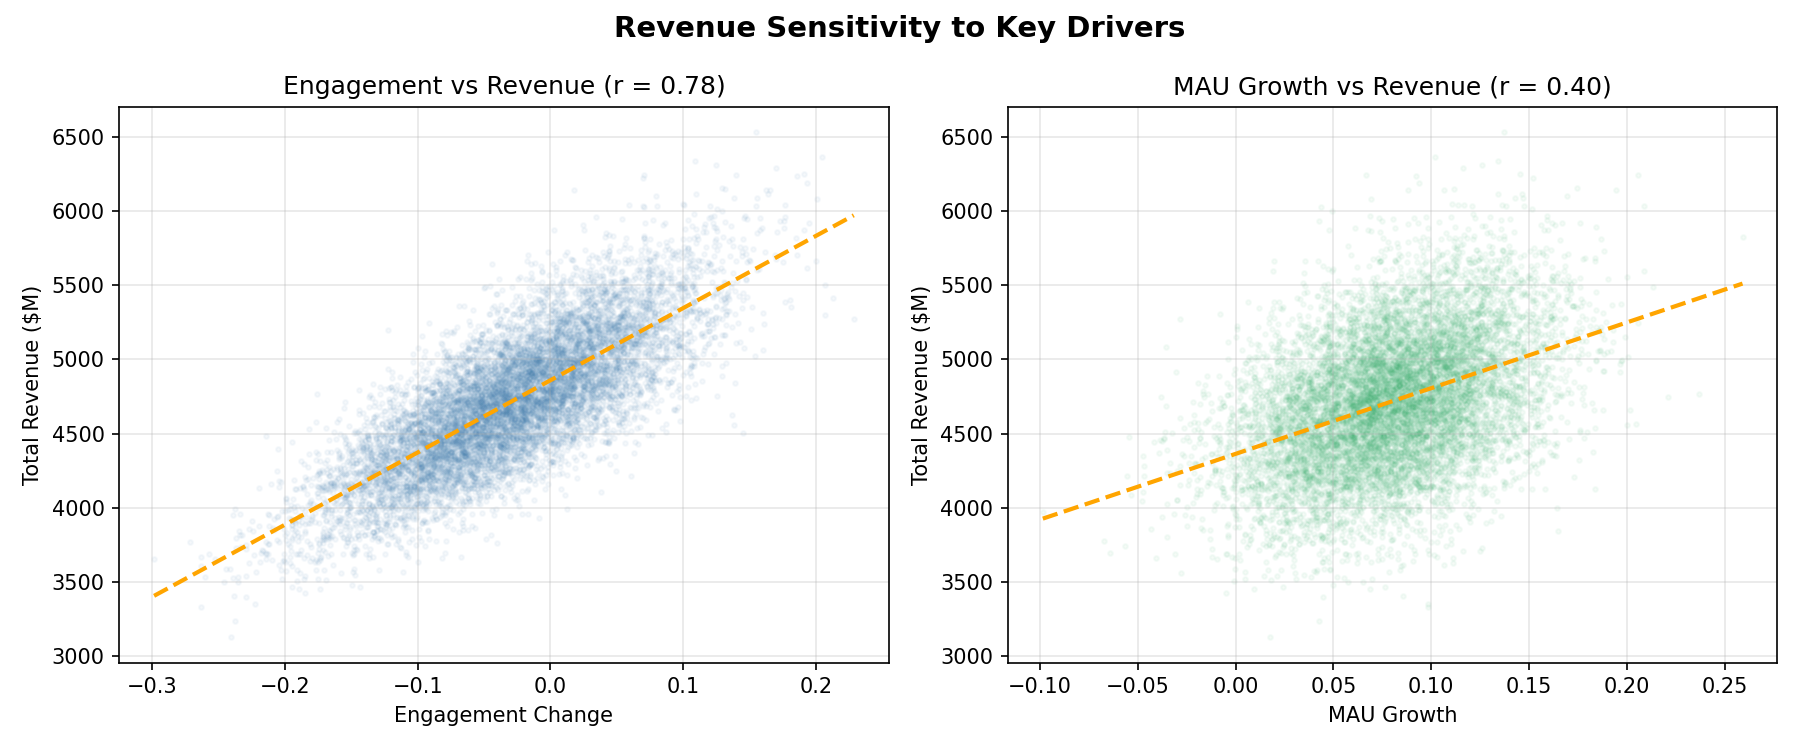

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# engagement vs revenue
ax1 = axes[0]
ax1.scatter(df['engagement'], df['total'], alpha=0.05, s=5, color='steelblue')
z = np.polyfit(df['engagement'], df['total'], 1)
x_line = np.linspace(df['engagement'].min(), df['engagement'].max(), 100)
ax1.plot(x_line, np.poly1d(z)(x_line), color='orange', lw=2, ls='--')
ax1.set_xlabel('Engagement Change')
ax1.set_ylabel('Total Revenue ($M)')
ax1.set_title(f'Engagement vs Revenue (r = {df["engagement"].corr(df["total"]):.2f})')
ax1.grid(True, alpha=0.3)

# mau growth vs revenue
ax2 = axes[1]
ax2.scatter(df['mau_growth'], df['total'], alpha=0.05, s=5, color='mediumseagreen')
z = np.polyfit(df['mau_growth'], df['total'], 1)
x_line = np.linspace(df['mau_growth'].min(), df['mau_growth'].max(), 100)
ax2.plot(x_line, np.poly1d(z)(x_line), color='orange', lw=2, ls='--')
ax2.set_xlabel('MAU Growth')
ax2.set_ylabel('Total Revenue ($M)')
ax2.set_title(f'MAU Growth vs Revenue (r = {df["mau_growth"].corr(df["total"]):.2f})')
ax2.grid(True, alpha=0.3)

plt.suptitle('Revenue Sensitivity to Key Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Engagement at r=0.78 is way ahead of MAU growth at r=0.40. That makes intuitive sense: you can have all the users in the world, but if they're not actually engaging (saving pins, clicking through, spending time on the platform), the ad inventory just isnt there.

This is probably the single most important chart for the AI disruption story. It's basically saying: if you want to know whether Pinterest's revenue goes up or down next year, watch the engagement numbers more than anything else.

## What I Took Away From This

1. **The expected case is growth.** ~$4.7B in revenue, about 12% above today. That's reassuring.

2. **But 1 in 8 simulations show a revenue decline.** 13% is not a small number when you're talking about a $4B+ company. You can't ignore it.

3. **Engagement is everything.** $1.2B revenue spread between the pessimistic and optimistic engagement scenarios. This is exactly the variable that AI disruption would hit: fewer sessions, less scrolling, less ad inventory.

4. **US concentration makes it worse.** 75% of revenue from one geography means any domestic headwind gets amplified across the whole P&L.

5. **The 90% confidence interval ($4.0B to $5.5B) is actually a useful planning tool.** Below $4B? Contingency plan time. Above $5.5B? The AI integration thesis is probably working.

Honestly the biggest thing I learned building this is that Monte Carlo simulation isn't magic. It's just asking "what if" a thousand times and counting the answers. The hard part isn't the code (its like 30 lines). The hard part is choosing the right parameters and knowing what the results actually mean for the business.

*Data: Pinterest 10-K (FY2024, FY2025). Not investment advice.*